In [4]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import optuna
import pandas as pd

from src.data_loader import load_data
from src.preprocessing import split_data, build_preprocessor
from src.modeling import build_xgboost_pipeline, evaluate_classification_model
from src.tuning import tune_xgboost

In [6]:
df = load_data()

X_train, X_test, y_train, y_test = split_data(df)
preprocessor = build_preprocessor(X_train)

In [7]:
study = tune_xgboost(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    n_trials=30,
    scoring="roc_auc"
)

[I 2026-04-04 13:42:42,247] A new study created in memory with name: no-name-594a76a7-dcc6-455f-9cd0-8c1da6e5f0c2
[I 2026-04-04 13:42:46,104] Trial 0 finished with value: 0.9436996045910465 and parameters: {'n_estimators': 372, 'max_depth': 4, 'learning_rate': 0.08741790203019009, 'subsample': 0.7541109789322912, 'colsample_bytree': 0.9208119257372266, 'min_child_weight': 6, 'gamma': 2.2753222701624596, 'reg_alpha': 0.2225348771100677, 'reg_lambda': 0.14964926243275442}. Best is trial 0 with value: 0.9436996045910465.
[I 2026-04-04 13:42:49,065] Trial 1 finished with value: 0.9444003668094012 and parameters: {'n_estimators': 114, 'max_depth': 7, 'learning_rate': 0.1297245389224963, 'subsample': 0.6365630621059075, 'colsample_bytree': 0.8091938716856631, 'min_child_weight': 8, 'gamma': 0.9371749615280506, 'reg_alpha': 1.098430210596194, 'reg_lambda': 0.31920571834208394}. Best is trial 1 with value: 0.9444003668094012.
[I 2026-04-04 13:42:52,191] Trial 2 finished with value: 0.947378572

In [8]:
print("Best ROC-AUC:", study.best_value)
print("Best params:")
study.best_params

Best ROC-AUC: 0.9500567700071668
Best params:


{'n_estimators': 291,
 'max_depth': 4,
 'learning_rate': 0.028293637122924282,
 'subsample': 0.8831214606575655,
 'colsample_bytree': 0.8723475105029491,
 'min_child_weight': 9,
 'gamma': 4.9141784645655395,
 'reg_alpha': 3.661584604480234,
 'reg_lambda': 2.4576819440806523}

In [9]:
best_xgb_model = build_xgboost_pipeline(
    preprocessor,
    **study.best_params
)

best_xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [10]:
metrics_xgb_tuned, report_xgb_tuned, cm_xgb_tuned = evaluate_classification_model(
    best_xgb_model, X_train, X_test, y_train, y_test
)

metrics_xgb_tuned

{'train_accuracy': 0.97025,
 'test_accuracy': 0.965,
 'train_precision': 0.9653979238754326,
 'test_precision': 0.9523809523809523,
 'train_recall': 0.9038876889848813,
 'test_recall': 0.8888888888888888,
 'train_f1': 0.9336307863915226,
 'test_f1': 0.9195402298850575,
 'train_roc_auc': 0.9521699096863403,
 'test_roc_auc': 0.943288888888889}

In [12]:
default_xgb_model = build_xgboost_pipeline(preprocessor)

default_xgb_model.fit(X_train, y_train)

metrics_xgb, report_xgb, cm_xgb = evaluate_classification_model(
    default_xgb_model, X_train, X_test, y_train, y_test
)

In [13]:
comparison_tuned = pd.DataFrame([
    {"model": "XGBoost Default", **metrics_xgb},
    {"model": "XGBoost Tuned", **metrics_xgb_tuned},
])

comparison_tuned.set_index("model")

,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
model,,,,,,,,,,
XGBoost Default,0.97125,0.965,0.965557,0.952381,0.908207,0.888889,0.936004,0.91954,0.997422,0.941958
XGBoost Tuned,0.97025,0.965,0.965398,0.952381,0.903888,0.888889,0.933631,0.91954,0.952170,0.943289


C:\Users\matei\AppData\Local\Temp\ipykernel_14340\1455980257.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

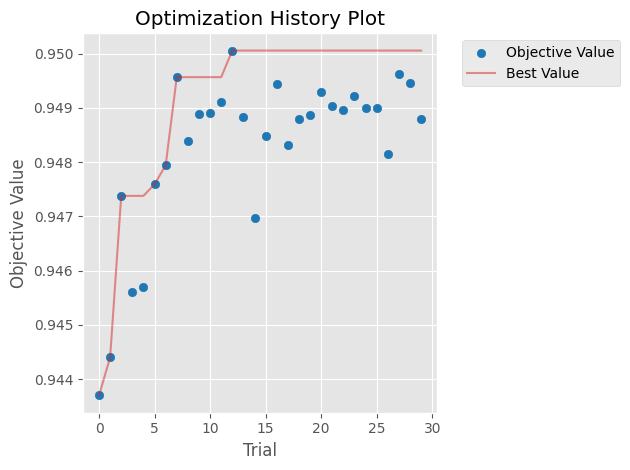

In [14]:
optuna.visualization.matplotlib.plot_optimization_history(study)

C:\Users\matei\AppData\Local\Temp\ipykernel_14340\1036994904.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

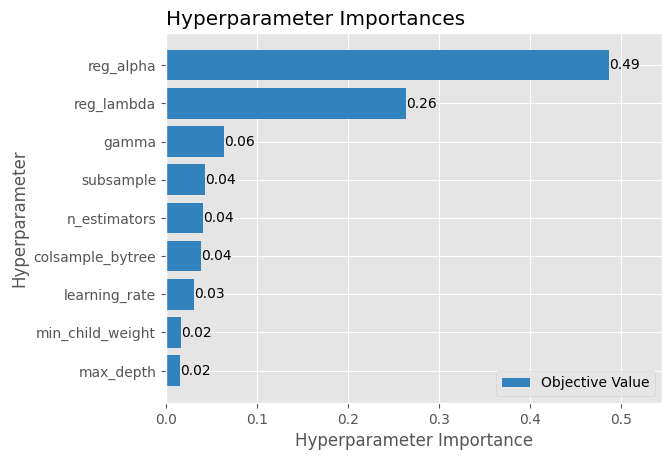

In [15]:
optuna.visualization.matplotlib.plot_param_importances(study)